# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')


In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from scipy.stats import truncnorm, norm
from scipy.optimize import fsolve

In [5]:
from core.variables import *
from core.dgp import SingleSegmentTreatmentSelection as SingleSegment
import core.treatment_selection_single_segment as ts
from core.selective_inference import *

# Toy Example

In [6]:
# settings
true_treat_effects = np.array([1, 1.01])
sample_size = 100  # per arm
sigma = 1
obs_vars = [
    UnivariateGaussian(mean=mean, std=sigma) for mean in true_treat_effects
]

# helper functions
def local_truncated_normal_cdf(x, mu, winner_std, loser_val) -> float:
    trunc_lb = (loser_val - mu) / winner_std

    return truncnorm.cdf(x, trunc_lb, np.inf, loc=mu, scale=winner_std)

def zero_func(mu, winner_val, winner_std, loser_val, quantile) -> float:
    return local_truncated_normal_cdf(winner_val, mu, winner_std, loser_val) - 1 + quantile

def find_zero_crossing(winner_val, winner_std, loser_val, quantile) -> float:
    return fsolve(
        lambda mu: zero_func(mu, winner_val, winner_std, loser_val, quantile), 
        x0=winner_val, 
        full_output=True, 
    )


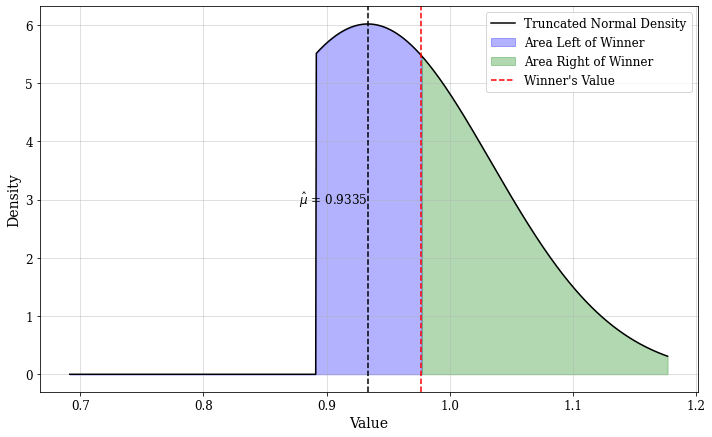

In [18]:
np.random.seed(3)

# simulation of one draw
samples = [
    var.sample(sample_size) for var in obs_vars
]

# estimate
est_treat_effects = np.array([sample.mean() for sample in samples])
est_treat_effects_vars = np.array([sample.var() for sample in samples])

# choose the winner 
winner_idx = np.argmax(est_treat_effects)
loser_idx = np.argmin(est_treat_effects)

# get the winner and loser values
winner_val = est_treat_effects[winner_idx]
loser_val = est_treat_effects[loser_idx]
winner_std = sigma / np.sqrt(sample_size)

# solve the problem
result = find_zero_crossing(
    winner_val=winner_val, 
    winner_std=winner_std, 
    loser_val=loser_val, 
    quantile=0.5
)
result

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

x = np.linspace(loser_val - 2 * winner_std, winner_val + 2 * winner_std.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (loser_val - result[0][0]) / winner_std, np.inf, loc=result[0][0], scale=winner_std)
ax.plot(x, y, color='black', label='Truncated Normal Density')

# Add area under curve with different shades
# Find indices for winner's value
winner_idx = np.argmin(np.abs(x - winner_val))
# Fill area to the left of winner's value
ax.fill_between(x[:winner_idx+1], y[:winner_idx+1], alpha=0.3, color='blue', label='Area Left of Winner')
# Fill area to the right of winner's value
ax.fill_between(x[winner_idx:], y[winner_idx:], alpha=0.3, color='green', label='Area Right of Winner')

ax.axvline(winner_val, color='red', linestyle='--', label="Winner's Value")
ax.axvline(result[0][0], color='black', linestyle='--')
ax.text(
    result[0][0] - 0.0, 0.5, 
    r'$\hat{\mu}$ = ' + f'{result[0][0]:.4f}', 
    transform=ax.get_xaxis_transform(), 
    verticalalignment='center', horizontalalignment='right', 
    fontsize=legend_label_size, 
)

ax.tick_params(axis='both', which='both', labelsize=tick_label_size)
ax.set_xlabel('Value', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
# ax.set_title(f"Density When Winner={winner_val:.4f} and Loser={loser_val:.4f}", fontsize=title_size)
ax.grid(alpha=0.5)
ax.legend(fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/regular_truncated_normal_density.jpg')
plt.show()

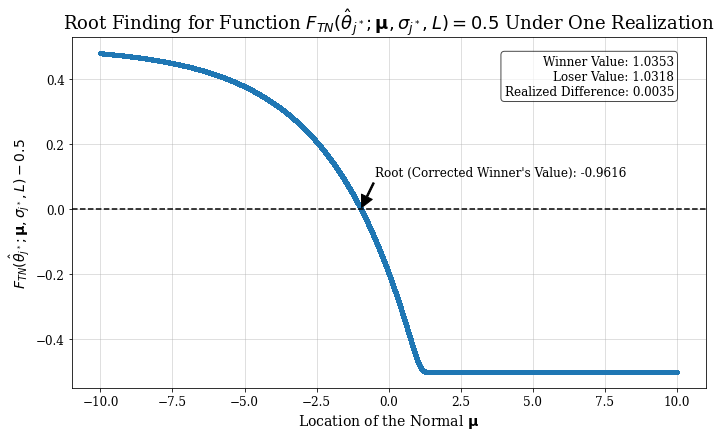

(array([-0.96162113]),
 {'nfev': 9,
  'fjac': array([[-1.]]),
  'r': array([0.17284437]),
  'qtf': array([8.8817842e-16]),
  'fvec': array([-8.8817842e-16])},
 1,
 'The solution converged.')

In [8]:
np.random.seed(4)

# simulation of one draw
samples = [
    var.sample(sample_size) for var in obs_vars
]

# estimate
est_treat_effects = np.array([sample.mean() for sample in samples])
est_treat_effects_vars = np.array([sample.var() for sample in samples])

# choose the winner 
winner_idx = np.argmax(est_treat_effects)
loser_idx = np.argmin(est_treat_effects)

# get the winner and loser values
winner_val = est_treat_effects[winner_idx]
loser_val = est_treat_effects[loser_idx]
winner_std = sigma / np.sqrt(sample_size)

# plot the zero function
mu_arr = np.linspace(-10, 10, 500000)
y_arr = zero_func(
    mu=mu_arr, 
    winner_val=winner_val, 
    winner_std=winner_std, 
    loser_val=loser_val, 
    quantile=0.5
)
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# equation
ax.plot(mu_arr, y_arr, 'o-', markersize=3)

# solution to the equation
ax.axhline(y=0, linestyle='--', color='black')
sol_idx = np.argmin(y_arr ** 2)
sol_x = mu_arr[sol_idx]
# ax.axvline(sol_x, linestyle='--', color='black')

# Add annotation with the coordinate of the solution point
ax.annotate(f'Root (Corrected Winner\'s Value): {sol_x:.4f}', 
            xy=(sol_x, 0), 
            xytext=(sol_x + 0.5, 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=legend_label_size)

# Add annotations in a box in the upper right corner
props = dict(boxstyle='round', facecolor='white', alpha=0.7)
textstr = f"Winner Value: {winner_val:.4f}\nLoser Value: {loser_val:.4f}\nRealized Difference: {winner_val-loser_val:.4f}"
ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=legend_label_size,
        verticalalignment='top', horizontalalignment='right', bbox=props)

ax.set_title(r'Root Finding for Function $F_{TN}(\hat{\theta}_{j^*}; \mathbf{\mu}, \sigma_{j^*}, L) = 0.5$ Under One Realization', fontsize=title_size)
ax.set_xlabel(r'Location of the Normal $\mathbf{\mu}$', fontsize=axis_label_size)
ax.set_ylabel(r'$F_{TN}(\hat{\theta}_{j^*}; \mathbf{\mu}, \sigma_{j^*}, L) - 0.5$', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid(alpha=0.5)
plt.tight_layout()
plt.show()

# solve the problem
result = find_zero_crossing(
    winner_val=winner_val, 
    winner_std=winner_std, 
    loser_val=loser_val, 
    quantile=0.5
)
result

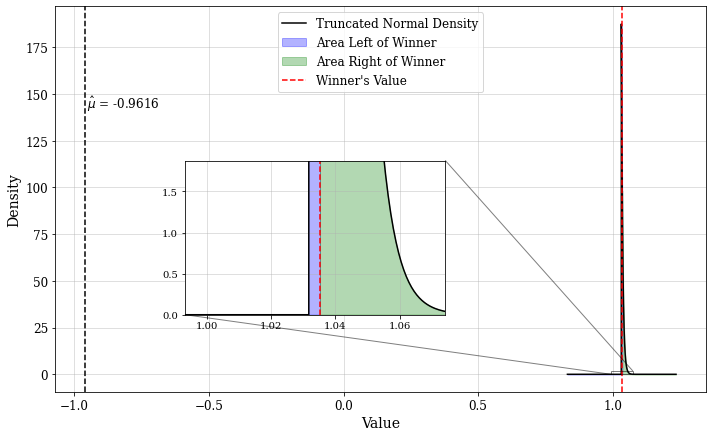

In [24]:
np.random.seed(4)

# simulation of one draw
samples = [
    var.sample(sample_size) for var in obs_vars
]

# estimate
est_treat_effects = np.array([sample.mean() for sample in samples])
est_treat_effects_vars = np.array([sample.var() for sample in samples])

# choose the winner 
winner_idx = np.argmax(est_treat_effects)
loser_idx = np.argmin(est_treat_effects)

# get the winner and loser values
winner_val = est_treat_effects[winner_idx]
loser_val = est_treat_effects[loser_idx]
winner_std = sigma / np.sqrt(sample_size)

# solve the problem
result = find_zero_crossing(
    winner_val=winner_val, 
    winner_std=winner_std, 
    loser_val=loser_val, 
    quantile=0.5
)
result


fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

x = np.linspace(loser_val - 2 * winner_std, winner_val + 2 * winner_std.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (loser_val - result[0][0]) / winner_std, np.inf, loc=result[0][0], scale=winner_std)
ax.plot(x, y, color='black', label='Truncated Normal Density')

# Add area under curve with different shades
# Find indices for winner's value
winner_idx = np.argmin(np.abs(x - winner_val))
# Fill area to the left of winner's value
ax.fill_between(x[:winner_idx+1], y[:winner_idx+1], alpha=0.3, color='blue', label='Area Left of Winner')
# Fill area to the right of winner's value
ax.fill_between(x[winner_idx:], y[winner_idx:], alpha=0.3, color='green', label='Area Right of Winner')

ax.axvline(winner_val, color='red', linestyle='--', label="Winner's Value")
ax.axvline(result[0][0], color='black', linestyle='--')
ax.text(
    result[0][0] + 0.01, 0.75, 
    r'$\hat{\mu}$ = ' + f'{result[0][0]:.4f}', 
    transform=ax.get_xaxis_transform(), 
    verticalalignment='center', horizontalalignment='left', 
    fontsize=legend_label_size, 
)

# Create an inset axes for the zoomed-in view of the PDF
axins_pdf = ax.inset_axes([0.2, 0.2, 0.4, 0.4])  # [x, y, width, height] in axes coordinates
# Add area under curve with different shades
# axins_pdf.plot(x, y_pdf, color='black')
axins_pdf.plot(x, y, color='black', label='Truncated Normal Distribution')
# Fill area to the left of winner's value
axins_pdf.fill_between(x[:winner_idx+1], y[:winner_idx+1], alpha=0.3, color='blue', label='Area Left of Winner')
# Fill area to the right of winner's value
axins_pdf.fill_between(x[winner_idx:], y[winner_idx:], alpha=0.3, color='green', label='Area Right of Winner')

# Set the limits for the inset axes to focus on the area around the estimated winner's value
x_min, x_max = x[400], x[-400]
y_min, y_max = 0, max(y) * 0.01
axins_pdf.set_xlim(x_min, x_max)
axins_pdf.set_ylim(y_min, y_max)
axins_pdf.axvline(winner_val, color='red', linestyle='--')
axins_pdf.axvline(result[0][0], color='black', linestyle='--')
axins_pdf.grid(True, alpha=0.5)
ax.indicate_inset_zoom(axins_pdf, edgecolor="black")

ax.tick_params(axis='both', which='both', labelsize=tick_label_size)
ax.set_xlabel('Value', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
# ax.set_title(f"Density When Winner={winner_val:.4f} and Loser={loser_val:.4f}", fontsize=title_size)
ax.grid(alpha=0.5)
ax.legend(fontsize=legend_label_size)

plt.tight_layout()
plt.savefig('figures/irregular_truncated_normal_density.jpg')
plt.show()

In [20]:
tau1 = 1
diff_arr = np.linspace(1e-5, 0.1, 5000)
tau2_arr = tau1 + diff_arr 
winner_std = 1 / np.sqrt(sample_size)

mu_hat_arr = np.array([
    find_zero_crossing(winner_val=tau2, winner_std=winner_std, loser_val=tau1, quantile=0.5)[0][0]
    for tau2 in tqdm(tau2_arr)
])

100%|██████████| 5000/5000 [00:03<00:00, 1359.76it/s]


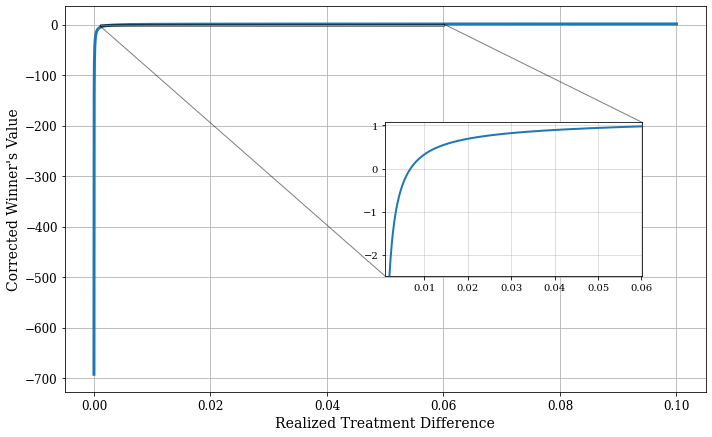

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.plot(diff_arr, mu_hat_arr, color='C0', label='Estimated', linewidth=3)
# ax.plot(diff_arr, tau1 + diff_arr, color='C1', label='True', linewidth=3)

# ax.set_title("Corrected Winner's Value vs. Realized Treatment Differences", fontsize=title_size)
ax.set_ylabel("Corrected Winner's Value", fontsize=axis_label_size)
ax.set_xlabel('Realized Treatment Difference', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
# ax.legend(fontsize=legend_label_size)
ax.grid()

# Create an inset axes for the zoomed-in view of the bottom left corner
axins = ax.inset_axes([0.5, 0.3, 0.4, 0.4])  # [x, y, width, height] in axes coordinates
axins.plot(diff_arr, mu_hat_arr, color='C0', linewidth=2)
# axins.plot(diff_arr, tau1 + diff_arr, color='C1', linewidth=2)

# Set the limits for the inset axes to focus on the bottom left corner
x_min, x_max = diff_arr[-4900], diff_arr[-2000]  # Adjust these values as needed
y_min, y_max = mu_hat_arr[-4900], mu_hat_arr[-2000]  # Adjust these values to show what's happening below 0
axins.set_xlim(x_min - 1e-3, x_max)
axins.set_ylim(y_min - 0.05, y_max + 0.1)
axins.grid(True, alpha=0.5)

# Add a box to indicate the zoomed region
ax.indicate_inset_zoom(axins, edgecolor="black")

plt.tight_layout()
plt.savefig('figures/corrected_winner_vs_diff.jpg')
plt.show()

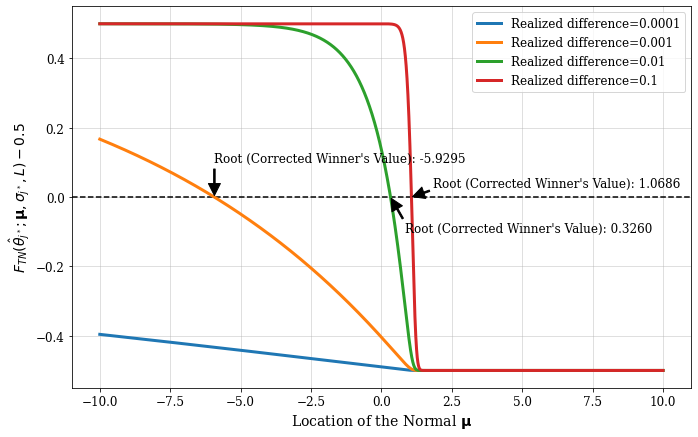

In [22]:
tau1 = 1
winner_std = 1 / np.sqrt(100)

# plot the zero function
mu_arr = np.linspace(-10, 10, 500000)


fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

ax.axhline(y=0, linestyle='--', color='black')


# delta = 1e-4
delta = 1e-4
y_arr = zero_func(
    mu=mu_arr, 
    winner_val=tau1 + delta, 
    winner_std=winner_std, 
    loser_val=tau1, 
    quantile=0.5
)
# equation
ax.plot(mu_arr, y_arr, '-', linewidth=3, label=f'Realized difference={delta}')

# delta = 1e-3
delta = 1e-3
y_arr = zero_func(
    mu=mu_arr, 
    winner_val=tau1 + delta, 
    winner_std=winner_std, 
    loser_val=tau1, 
    quantile=0.5
)
# equation
ax.plot(mu_arr, y_arr, '-', linewidth=3, label=f'Realized difference={delta}')
# solution to the equation
sol_idx = np.argmin(y_arr ** 2)
sol_x = mu_arr[sol_idx]
# Add annotation with the coordinate of the solution point
ax.annotate(f'Root (Corrected Winner\'s Value): {sol_x:.4f}', 
            xy=(sol_x, 0), 
            xytext=(sol_x, 0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=legend_label_size)

# delta = 1e-2
delta = 1e-2
y_arr = zero_func(
    mu=mu_arr, 
    winner_val=tau1 + delta, 
    winner_std=winner_std, 
    loser_val=tau1, 
    quantile=0.5
)
# equation
ax.plot(mu_arr, y_arr, '-', linewidth=3, label=f'Realized difference={delta}')
# solution to the equation
sol_idx = np.argmin(y_arr ** 2)
sol_x = mu_arr[sol_idx]
# Add annotation with the coordinate of the solution point
ax.annotate(f'Root (Corrected Winner\'s Value): {sol_x:.4f}', 
            xy=(sol_x, 0), 
            xytext=(sol_x + 0.5, -0.1),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=legend_label_size)


# delta = 1e-1
delta = 1e-1
y_arr = zero_func(
    mu=mu_arr, 
    winner_val=tau1 + delta, 
    winner_std=winner_std, 
    loser_val=tau1, 
    quantile=0.5
)
# equation
ax.plot(mu_arr, y_arr, '-', linewidth=3, label=f'Realized difference={delta}')
# solution to the equation
sol_idx = np.argmin(y_arr ** 2)
sol_x = mu_arr[sol_idx]
# Add annotation with the coordinate of the solution point
ax.annotate(f'Root (Corrected Winner\'s Value): {sol_x:.4f}', 
            xy=(sol_x, 0), 
            xytext=(sol_x + 0.75, 0.03),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
            fontsize=legend_label_size)

# ax.set_title(r'Root Finding for Function $F_{TN}(\hat{\theta}_{j^*}; \mathbf{\mu}, \sigma_{j^*}, L) = 0.5$', fontsize=title_size)
ax.set_xlabel(r'Location of the Normal $\mathbf{\mu}$', fontsize=axis_label_size)
ax.set_ylabel(r'$F_{TN}(\hat{\theta}_{j^*}; \mathbf{\mu}, \sigma_{j^*}, L) - 0.5$', fontsize=axis_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid(alpha=0.5)
ax.legend(fontsize=legend_label_size)
plt.tight_layout()
plt.savefig('figures/zero_function_of_truncated_normal.jpg')
plt.show()


# Jobstart

In [6]:
params_dict = {
    'Atlanta Job Corps': (2093, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (785, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

mu_arr = np.array([params_dict[site][0] for site in params_dict])
se_arr = np.array([params_dict[site][1] for site in params_dict])
cov_arr = np.diag(se_arr ** 2)  # the paper uses standard errors to contruct the covariance matrix

best_site_mu, best_site_se = params_dict['CET/San Jose']

best_scaling = 0.55

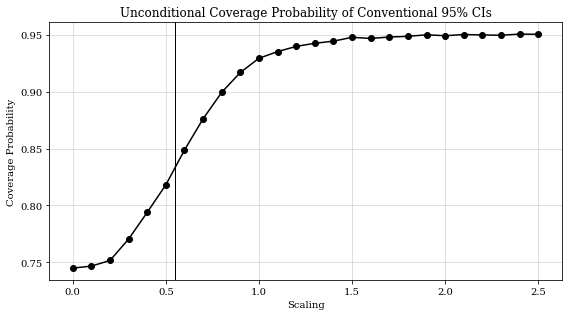

In [7]:
# coverage of conventional 95% CI
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
coverage_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]
    best_se_arr = se_arr[temp_best_site_arr]

    is_cover_arr = (best_mu_arr - 1.96 * best_se_arr <= max_est_arr) & (max_est_arr <= best_mu_arr + 1.96 * best_se_arr)
    coverage_arr[idx] = is_cover_arr.mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, coverage_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Coverage Probability')
ax.set_title('Unconditional Coverage Probability of Conventional 95% CIs')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, coverage_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr, best_se_arr, is_cover_arr

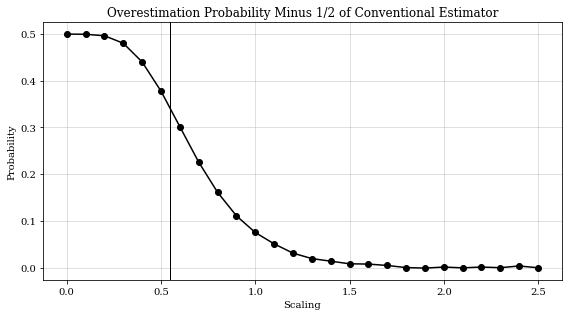

In [8]:
# Overestimation probability
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
overestimate_prob_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    overestimate_prob_arr[idx] = (max_est_arr >= best_mu_arr).mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, overestimate_prob_arr - 0.5, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Probability')
ax.set_title('Overestimation Probability Minus 1/2 of Conventional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, overestimate_prob_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

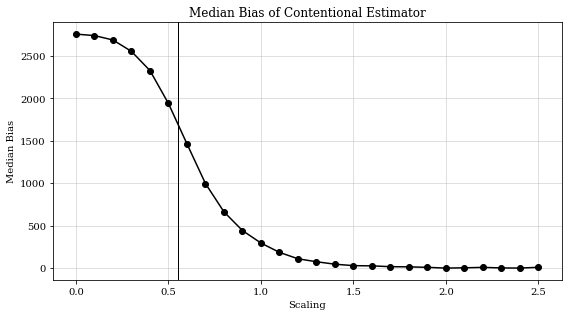

In [9]:
# median bias
n_repeats = 100000 
scaling_arr = np.arange(0, 2.6, 0.1)
median_bias_arr = np.zeros_like(scaling_arr)

for idx, scaling in enumerate(scaling_arr):
    data_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, n_repeats)  # shape = (n_repeats, n_sites)
    temp_best_site_arr = data_arr.argmax(axis=1)  # shape = (n_repeats,)
    max_est_arr = data_arr[np.arange(n_repeats), data_arr.argmax(axis=1)]  # shape = (n_repeats,)
    best_mu_arr = scaling * mu_arr[temp_best_site_arr]  # shape = (n_repeats,)

    median_bias_arr[idx] = np.median(max_est_arr - best_mu_arr)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(scaling_arr, median_bias_arr, marker='o', color='black')
ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)
ax.set_xlabel('Scaling')
ax.set_ylabel('Median Bias')
ax.set_title('Median Bias of Contentional Estimator')
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

del n_repeats, scaling_arr, median_bias_arr, data_arr, temp_best_site_arr, max_est_arr, best_mu_arr

# Model

In [10]:
params_dict = {
    'Atlanta Job Corps': (2093, 2288.40), 
    'CET/San Jose': (6547, 1496.17), 
    'Chicago Commons': (-1417, 2168.21), 
    'Connelley (Pittsburgh)': (785, 1681.92), 
    'East LA Skills Center': (1343, 1735.51), 
    'EGOS (Denver)': (401, 1329.05), 
    'Phoenix Job Corps': (-1325, 1598.03), 
    'SET/Corpus Christi': (485, 971.05), 
    'EI Centro (Dallas)': (336, 1523.33), 
    'LA Job Corps': (-121, 1409.79), 
    'Allentown (Buffalo)': (904, 1814.10), 
    'BSA (New York City)': (1424, 1768.44), 
    'CREC (Hartford)': (-1370, 1860.45), 
}

mu_arr = np.array([params_dict[site][0] for site in params_dict])
se_arr = np.array([params_dict[site][1] for site in params_dict])
cov_arr = np.diag(se_arr ** 2)  # the paper uses standard errors to contruct the covariance matrix

best_site_mu, best_site_se = params_dict['CET/San Jose']

best_scaling = 0.55

## Conditional Inference

In [11]:
mean_arr = mu_arr
std_arr = se_arr

# calculate the related statistics
max_item_idx = mean_arr.argmax()
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the quantile
result = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)
median_est = result[0][0]

print('Median Estimate:', median_est)

Median Estimate: 6544.253866680862


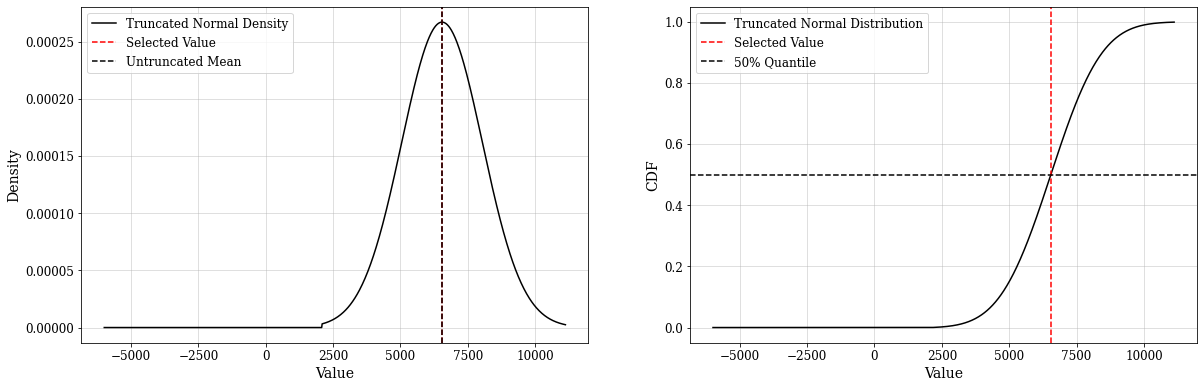

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(mean_arr.min() - 2 * std_arr.max(), mean_arr.max() + 2 * std_arr.max(), 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].set_ylabel('Density', fontsize=axis_label_size)
axes[0].axvline(median_est, color='black', linestyle='--', label='Untruncated Mean')

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (second_max_mean - median_est) / max_item_std, np.inf, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [13]:
n_repeats = 5000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
    ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
    ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
        'est': median_est, 
    }

100%|██████████| 5000/5000 [00:16<00:00, 306.99it/s]


In [14]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
err_std = result_df['error'].std()
ci_width = result_df['ci_width'].median()

avg = result_df['est'].mean()
median = result_df['est'].median()

print(f'Average', avg)
print(f'Median', median)

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Error Std: {err_std:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Average -6064.279358320802
Median 2627.9497709629945
Coverage Probability: 95.20%
Overestimation Probability: 49.44%
Average Error: -8431.35
Median Error: -38.84
Error Std: 108810.60
Median CI Width: 12953.56


## Unconditional Inference

In [11]:
n_repeats = 100
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    ci_lb, ci_ub, _ = unconditional_inference(
        mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha, 
        n_simulations=100000
    )

    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
    }

100%|██████████| 100/100 [00:03<00:00, 31.27it/s]


In [12]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
ci_width = result_df['ci_width'].median()

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Median CI Width: {ci_width:.2f}')

Coverage Probability: 97.00%
Median CI Width: 8634.06


## Hybrid

In [7]:
mean_arr = mu_arr
std_arr = se_arr

# calculate beta
alpha = 0.05
beta = alpha / 10

# if max_item_idx is not provided, find the index of the max item
max_item_idx = mean_arr.argmax()

# get the mean and std of the max item
max_item_mean, max_item_std = mean_arr[max_item_idx], std_arr[max_item_idx]

# calculate c_beta from projection method
_, _, c_beta = unconditional_inference(
    mean_arr, std_arr, max_item_idx=max_item_idx, alpha=beta, 
    n_simulations=500000
)

# get the second max mean
second_max_mean = np.delete(mean_arr, max_item_idx).max()

# calculate the lb and ub of the truncated normal distribution
trunc_lb = max(second_max_mean, max_item_mean - c_beta * max_item_std)
trunc_ub = max_item_mean + c_beta * max_item_std
# trunc_ub = np.inf

# calculate the quantile
median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]

print('Truncated normal distribution: ')
print(f'Mean: {median_est:.2f}, SD: {max_item_std:.2f}')
print(f'Lower bound: {trunc_lb:.2f}, Upper bound: {trunc_ub:.2f}')

Truncated normal distribution: 
Mean: 6544.64, SD: 1496.17
Lower bound: 2093.00, Upper bound: 11865.02


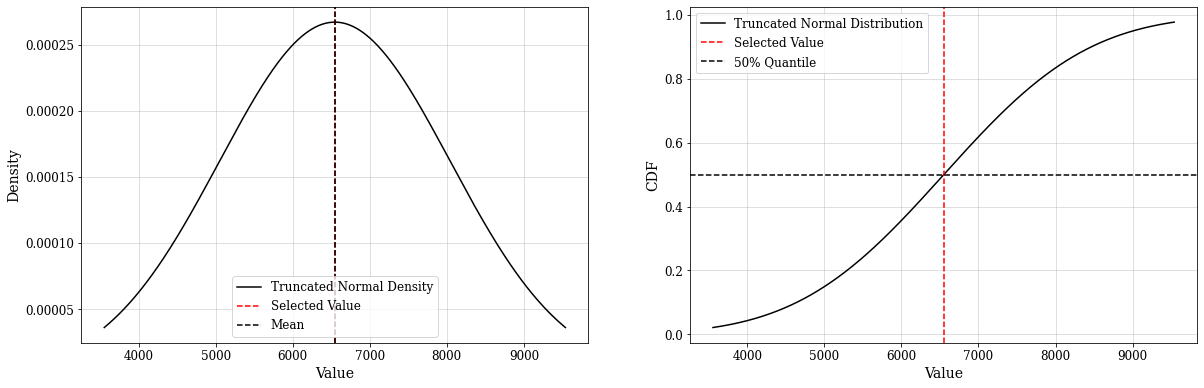

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

x = np.linspace(median_est - 2 * max_item_std, median_est + 2 * max_item_std, 1000)

# plot the pdf of truncated normal distribution
y = truncnorm.pdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[0].plot(x, y, color='black', label='Truncated Normal Density')
axes[0].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[0].axvline(truncnorm.mean(a=(second_max_mean - median_est) / max_item_std, b=np.inf, loc=median_est, scale=max_item_std), color='black', linestyle='--', label='Mean')
axes[0].set_ylabel('Density', fontsize=axis_label_size)

# plt the cdf of truncated normal distribution
y = truncnorm.cdf(x, (trunc_lb - median_est) / max_item_std, (trunc_ub - median_est) / max_item_std, loc=median_est, scale=max_item_std)
axes[1].plot(x, y, color='black', label='Truncated Normal Distribution')
axes[1].axvline(max_item_mean, color='red', linestyle='--', label='Selected Value')
axes[1].axhline(0.5, color='black', linestyle='--', label='50% Quantile')
axes[1].set_ylabel('CDF', fontsize=axis_label_size)

for ax in axes:
    ax.grid(True, alpha=0.5)
    ax.set_xlabel('Value', fontsize=axis_label_size)
    ax.legend(fontsize=legend_label_size)
    ax.tick_params(axis='both', which='major', labelsize=tick_label_size)


plt.show()

In [17]:
n_repeats = 1000
alpha = 0.05
scaling = best_scaling
result_records = [None] * n_repeats

for idx in tqdm(range(n_repeats)):
    mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
    std_arr = np.sqrt(np.diag(cov_arr))

    max_item_idx = mean_arr.argmax()
    max_item_val_true = scaling * mu_arr[max_item_idx]

    # calculate the quantile
    median_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
    ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
    ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]


    result_records[idx] = {
        'ci_width': ci_ub - ci_lb,
        'error': median_est - max_item_val_true,
        'is_overestimate': median_est >= max_item_val_true, 
        'is_cover': ci_lb <= max_item_val_true <= ci_ub, 
        'est': median_est,
    }

100%|██████████| 1000/1000 [00:23<00:00, 42.17it/s]


In [18]:
result_df = pd.DataFrame.from_records(result_records)

cover_pct = result_df['is_cover'].mean()
overestimate_pct = result_df['is_overestimate'].mean()
avg_err = result_df['error'].mean()
median_err = result_df['error'].median()
ci_width = result_df['ci_width'].median()

print('Average', result_df['est'].mean())
print('Median', result_df['est'].median())

print(f'Coverage Probability: {cover_pct:.2%}')
print(f'Overestimation Probability: {overestimate_pct:.2%}')
print(f'Average Error: {avg_err:.2f}')
print(f'Median Error: {median_err:.2f}')
print(f'Median CI Width: {ci_width:.2f}')

Average 2282.909555544169
Median 2741.740975399099
Coverage Probability: 95.80%
Overestimation Probability: 51.10%
Average Error: -58.94
Median Error: 98.83
Median CI Width: 8397.49


## Comparison

In [19]:
n_repeats = 100
alpha = 0.05
scaling_arr = np.arange(0, 2.6, 0.1)
result_records = [None] * (scaling_arr.size * n_repeats)

for idx, scaling in tqdm(enumerate(scaling_arr)):
    for j in range(n_repeats):
        mean_arr = np.random.multivariate_normal(scaling * mu_arr, cov_arr, 1).flatten()
        std_arr = np.sqrt(np.diag(cov_arr))

        max_item_idx = mean_arr.argmax()
        max_item_val_true = scaling * mu_arr[max_item_idx]

        # Conventional
        conv_ci_lb = mean_arr[max_item_idx] - 1.96 * std_arr[max_item_idx]
        conv_ci_ub = mean_arr[max_item_idx] + 1.96 * std_arr[max_item_idx]

        # Conditional Inference
        cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
        cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

        # Unconditional Inference
        uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

        # Hybrid Inference
        hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
        hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]

        result_records[idx * n_repeats + j] = {
            'scaling': scaling, 
            'conv_ci_width': conv_ci_ub - conv_ci_lb,
            'cond_ci_width': cond_ci_ub - cond_ci_lb, 
            'uncond_ci_width': uncond_ci_ub - uncond_ci_lb,
            'hybrid_ci_width': hybrid_ci_ub - hybrid_ci_lb,
        }

26it [00:52,  2.01s/it]


In [20]:
result_df = pd.DataFrame.from_records(result_records)
median_ci_width_df = result_df.groupby('scaling').median()

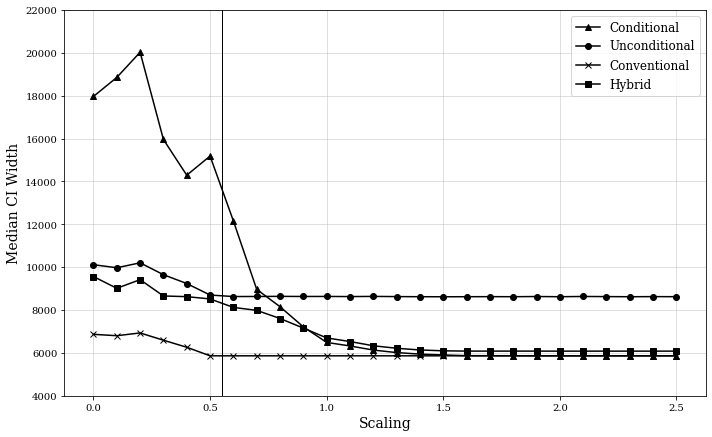

In [21]:
fig, ax = plt.subplots(figsize=(10, 6.18))

ax.plot(median_ci_width_df.index, median_ci_width_df['cond_ci_width'], marker='^', color='black', label='Conditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['uncond_ci_width'], marker='o', color='black', label='Unconditional')
ax.plot(median_ci_width_df.index, median_ci_width_df['conv_ci_width'], marker='x', color='black', label='Conventional')
ax.plot(median_ci_width_df.index, median_ci_width_df['hybrid_ci_width'], marker='s', color='black', label='Hybrid')

ax.axvline(best_scaling, color='black', linestyle='-', linewidth=1)

ax.set_xlabel('Scaling', fontsize=axis_label_size)
ax.set_ylabel('Median CI Width', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid(True, alpha=0.5)

ax.set_ylim(4000, 22000)

plt.tight_layout()
plt.show()

In [8]:
# results summary
alpha = 0.05
mean_arr = mu_arr 
std_arr = se_arr

max_item_idx = mean_arr.argmax()

# conventional
conv_est = mean_arr[max_item_idx]
conv_ci_lb = mean_arr[max_item_idx] - norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]
conv_ci_ub = mean_arr[max_item_idx] + norm.ppf(1 - alpha / 2) * std_arr[max_item_idx]

# conditional inference
cond_est = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
cond_ci_lb = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=alpha / 2)[0][0]
cond_ci_ub = conditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - alpha / 2)[0][0]

# unconditional inference
uncond_est = conv_est 
uncond_ci_lb, uncond_ci_ub, _ = unconditional_inference(mean_arr, std_arr, max_item_idx=max_item_idx, alpha=alpha)

# hybrid inference
hybrid_est = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=0.5)[0][0]
hybrid_ci_lb = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=(alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]
hybrid_ci_ub = hybrid_inference(mean_arr, std_arr, max_item_idx=max_item_idx, quantile=1 - (alpha - 0.1 * alpha) / (2 * (1 - 0.1 * alpha)))[0][0]

corrected_inference_df = pd.DataFrame({
    'Conventional': {'Point Estimate': f'${conv_est}', 'CI': f'(${conv_ci_lb:.0f}, ${conv_ci_ub:.0f})'},
    'Conditional': {'Point Estimate': f'${cond_est:.0f}', 'CI': f'(${cond_ci_lb:.0f}, ${cond_ci_ub:.0f})'},
    'Unconditional': {'Point Estimate': f'${uncond_est}', 'CI': f'(${uncond_ci_lb:.0f}, ${uncond_ci_ub:.0f})'},
    'Hybrid': {'Point Estimate': f'${hybrid_est:.0f}', 'CI': f'(${hybrid_ci_lb:.0f}, ${hybrid_ci_ub:.0f})'},
}).T
corrected_inference_df

,Point Estimate,CI
Conventional,$6547,"($3615, $9479)"
Conditional,$6544,"($3494, $9479)"
Unconditional,$6547,"($2239, $10855)"
Hybrid,$6545,"($3429, $9577)"
